# iso codes

In [14]:
import arxiv
import re
from iso639.language import ALL_LANGUAGES
from datetime import datetime, timedelta

# Construct the default API client.
client = arxiv.Client()

# Calculate date range for last 7 days
end_date = datetime.now()
start_date = end_date - timedelta(days=7)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")

# Build query with category and date filter
query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
search = arxiv.Search(query=query, max_results=50, sort_by=arxiv.SortCriterion.SubmittedDate)

results = client.results(search)
for result in results:
    abstract = result.summary
    title = result.title
    
    # 2. Hard constraint: Only look for languages explicitly mentioned in Title/Abstract
    detected_languages = []
    false_positives = {"English", "Modern", "Program", "The", "Are", "Day"}
    
    for lang in ALL_LANGUAGES:
        name = lang.name
        alpha3 = lang.part3
        if not name or not alpha3:
            continue
        # Avoid short matching like 'it' or 'no' by matching full words and require name length >=4
        if len(name) < 4:
            continue
        pattern = r"\b" + re.escape(name) + r"\b"
        if re.search(pattern, abstract, re.IGNORECASE) or re.search(pattern, title, re.IGNORECASE):
            if name not in false_positives:
                detected_languages.append(f"{name} ({alpha3})")  # Full language name with code

    # Example output
    print(f"Title: {title}")
    print(f"Detected languages: {detected_languages}")


Title: ATLAS: Agentic or Latent Visual Reasoning? One Word is Enough for Both
Detected languages: []
Title: FutureSim: Replaying World Events to Evaluate Adaptive Agents
Detected languages: []
Title: Is Grep All You Need? How Agent Harnesses Reshape Agentic Search
Detected languages: ['Even (eve)']
Title: MetaBackdoor: Exploiting Positional Encoding as a Backdoor Attack Surface in LLMs
Detected languages: ['Even (eve)']
Title: Text Knows What, Tables Know When: Clinical Timeline Reconstruction via Retrieval-Augmented Multimodal Alignment
Detected languages: []
Title: MeMo: Memory as a Model
Detected languages: []
Title: Self-Distilled Agentic Reinforcement Learning
Detected languages: []
Title: Forgetting That Sticks: Quantization-Permanent Unlearning via Circuit Attribution
Detected languages: []
Title: MemEye: A Visual-Centric Evaluation Framework for Multimodal Agent Memory
Detected languages: []
Title: Talk is (Not) Cheap: A Taxonomy and Benchmark Coverage Audit for LLM Attacks
Det

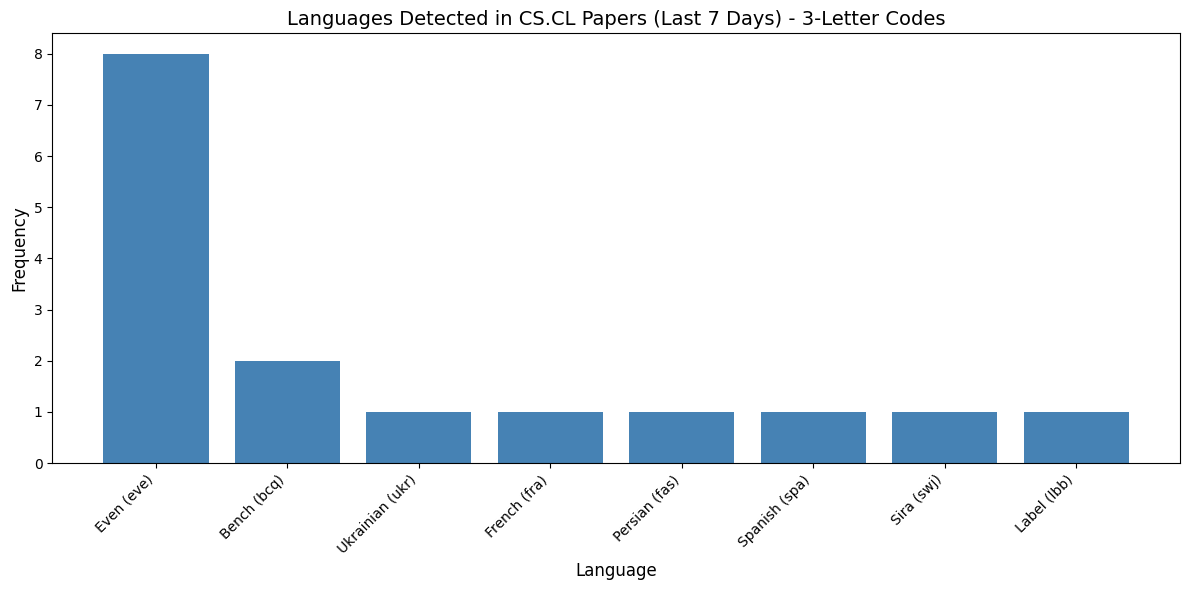

Total papers analyzed: 50
Total language mentions detected: 16
Unique languages detected: 8


In [15]:
import matplotlib.pyplot as plt
from collections import Counter
import arxiv
import re
from iso639.language import ALL_LANGUAGES
from datetime import datetime, timedelta

# Construct the default API client.
client = arxiv.Client()

# Calculate date range for last 7 days
end_date = datetime.now()
start_date = end_date - timedelta(days=7)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")

# Build query with category and date filter
query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
search = arxiv.Search(query=query, max_results=50, sort_by=arxiv.SortCriterion.SubmittedDate)

# Collect all detected languages (with codes)
all_detected_languages = []
false_positives = {"English", "Modern", "Program", "The", "Are", "Day"}

results = client.results(search)
for result in results:
    abstract = result.summary
    title = result.title
    detected_languages = []
    
    for lang in ALL_LANGUAGES:
        name = lang.name
        alpha3 = lang.part3
        if not name or not alpha3:
            continue
        if len(name) < 4:
            continue
        pattern = r"\b" + re.escape(name) + r"\b"
        if re.search(pattern, abstract, re.IGNORECASE) or re.search(pattern, title, re.IGNORECASE):
            if name not in false_positives:
                detected_languages.append(f"{name} ({alpha3})")
    
    all_detected_languages.extend(detected_languages)

# Count language occurrences
language_counter = Counter(all_detected_languages)

if language_counter:
    # Get top 10 most detected languages
    top_languages = language_counter.most_common(10)
    display_names, counts = zip(*top_languages)
    
    # Create bar chart
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(display_names)), counts, color='steelblue')
    plt.xticks(range(len(display_names)), display_names, rotation=45, ha='right')
    plt.xlabel('Language', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Languages Detected in CS.CL Papers (Last 7 Days) - 3-Letter Codes', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"Total papers analyzed: {len(list(client.results(search)))}")
    print(f"Total language mentions detected: {len(all_detected_languages)}")
    print(f"Unique languages detected: {len(language_counter)}")
else:
    print("No languages detected in papers from the last 7 days.")


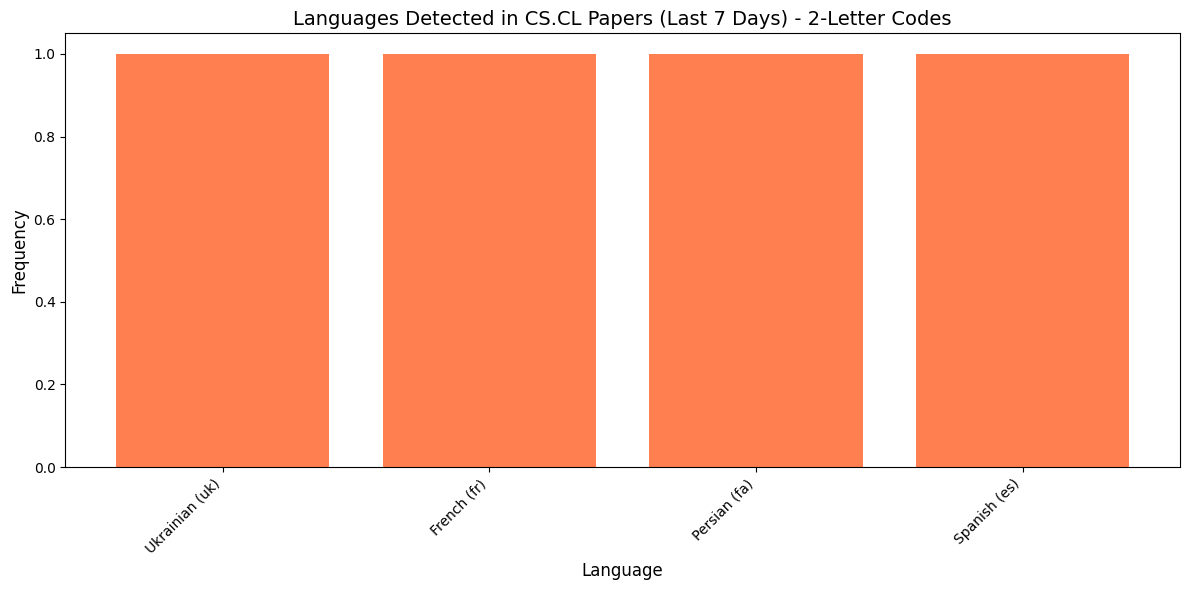

Total papers analyzed: 50
Total language mentions detected: 4
Unique languages detected: 4


In [16]:
import matplotlib.pyplot as plt
from collections import Counter
import arxiv
import re
from iso639.language import ALL_LANGUAGES
from datetime import datetime, timedelta

# Construct the default API client.
client = arxiv.Client()

# Calculate date range for last 7 days
end_date = datetime.now()
start_date = end_date - timedelta(days=7)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")

# Build query with category and date filter
query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
search = arxiv.Search(query=query, max_results=50, sort_by=arxiv.SortCriterion.SubmittedDate)

# Collect all detected languages using 2-letter codes (ISO 639-1)
all_detected_languages_2letter = []
false_positives = {"English", "Modern", "Program", "The", "Are", "Day"}

results = client.results(search)
for result in results:
    abstract = result.summary
    title = result.title
    detected_languages = []
    
    for lang in ALL_LANGUAGES:
        name = lang.name
        part1 = lang.part1  # 2-letter code
        if not name or not part1:
            continue
        if len(name) < 4:
            continue
        pattern = r"\b" + re.escape(name) + r"\b"
        if re.search(pattern, abstract, re.IGNORECASE) or re.search(pattern, title, re.IGNORECASE):
            if name not in false_positives:
                detected_languages.append(f"{name} ({part1})")
    
    all_detected_languages_2letter.extend(detected_languages)

# Count language occurrences
language_counter_2letter = Counter(all_detected_languages_2letter)

if language_counter_2letter:
    # Get top 10 most detected languages
    top_languages_2letter = language_counter_2letter.most_common(10)
    display_names_2letter, counts_2letter = zip(*top_languages_2letter)
    
    # Create bar chart
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(display_names_2letter)), counts_2letter, color='coral')
    plt.xticks(range(len(display_names_2letter)), display_names_2letter, rotation=45, ha='right')
    plt.xlabel('Language', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Languages Detected in CS.CL Papers (Last 7 Days) - 2-Letter Codes', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"Total papers analyzed: {len(list(client.results(search)))}")
    print(f"Total language mentions detected: {len(all_detected_languages_2letter)}")
    print(f"Unique languages detected: {len(language_counter_2letter)}")
else:
    print("No languages detected in papers from the last 7 days.")


# from some language code repo (lang filter)

In [3]:
import arxiv
import re
from datetime import datetime, timedelta
import time
import json, os

In [9]:
# from https://github.com/dilithjay/Shoulders-of-Giants/blob/main/categorize_filtered_papers.ipynb

def replace_non_letters_with_spaces(input_string):
    # Replace non-letter characters with spaces
    result_string = re.sub(r'[^a-zA-ZÀ-ÿ ]', ' ', input_string)
    return result_string

# Define languages to ignore 
languages_to_ignore ="Apache,Laura,Fang,Mono,Ma,Maria,Sam,Bench,Zhuang,Male,Nara,So,Hu,Kim,Label,The,To,Yong,The,To,Adele,Are,Foma,Kaur,Bau,Kato,Dek,Naman,Dom,As,The,To,As,Dan,E,The,To,U,Even,En,Chung,Dong,Shi,Tai,Thompson,Gao,Ir,Pan,Ali,Rao,Han,Doe,Titan,Ha,Sa,Tu,Lau,Siri,Wan,She,Dai,Ding,Kang,Ge,Koch,Che,Mann,Zou,Pei,Yao,Lou,Sydney,Ju,Sha,Day,Miwa,Bai,Ko,Ga,Pal,Pe,Gun,Hung,Con,Cun,Serrano,Sui,Bu,Mehri,Od,Haji,Gal,Gey,Lui,Ho,Furu,Ak,Kao,Aro,Gen,Moro,Notre,Ido,Ron,Were,Bai,Sahu,Dem,Melo,Rama,Hunde,Dii,Yala,Sauri".split(',')
languages_to_ignore=languages_to_ignore+"Uni,One,Yi,Na,Bit,Pa".split(',') + ["are", "as", "e", "en", "even", "one", "so", "to", "apache", "au", "u", "bit", "she", "siri", "day", "gun", "label", "notre"]
languages_to_ignore = set(languages_to_ignore)

# Load lang_classes from categorize_filtered_papers.ipynb
lang_classes = {}
base_path = "../Some-Languages-are-More-Equal-than-Others/Language_List/Language_Classes_According_To/DataSet_Availability"

for i in range(6):
    file_path = f"{base_path}/{i}.txt"
    try:
        with open(file_path, "r", encoding="utf-8") as fp:
            lang_classes[i] = set(fp.read().strip().split("\n"))
            print(f"✓ Loaded class {i}: {len(lang_classes[i])} languages")
    except FileNotFoundError:
        print(f"✗ Could not find file for class {i}: {file_path}")

print(f"Total unique languages across all classes: {len(set.union(*lang_classes.values()))}")
print(f"Total languages to ignore: {len(languages_to_ignore)}")
# print(f"lang classes: {lang_classes}")

# save lang_classes and languages_to_ignore for later use
output_data = {
    "lang_classes": {str(k): list(v) for k, v in lang_classes.items()},
    "languages_to_ignore": list(languages_to_ignore)
}   
print(f"Output data sample: {json.dumps(output_data, ensure_ascii=False, indent=4)[:500]}...")
output_file = "../data/processed/language_data.json"
with open(output_file, "w", encoding="utf-8") as fp:
    json.dump(output_data, fp, ensure_ascii=False, indent=4)
print(f"Saved language data to {output_file}")

✓ Loaded class 0: 6134 languages
✓ Loaded class 1: 130 languages
✓ Loaded class 2: 96 languages
✓ Loaded class 3: 30 languages
✓ Loaded class 4: 22 languages
✓ Loaded class 5: 7 languages
Total unique languages across all classes: 6418
Total languages to ignore: 130
Output data sample: {
    "lang_classes": {
        "0": [
            "Magiyi",
            "Mundat",
            "Yuanga",
            "Mangarrayi",
            "Akha",
            "Bukpe",
            "Kpatili",
            "Amba",
            "Ifè",
            "Wappo",
            "Gende",
            "Virgin Islands English Creole",
            "Maiwala",
            "Rungus",
            "Vao",
            "Iten",
            "Gangte",
            "Jilbe",
            "Marimanindji",
            "Mbe",
     ...
Saved language data to ../data/processed/language_data.json


In [ ]:
# read back the saved data
output_file = "../data/processed/language_data.json"
if os.path.exists(output_file):
    with open(output_file, "r", encoding="utf-8") as fp:
        loaded_data = json.load(fp)
        lang_classes = {int(k): set(v) for k, v in loaded_data["lang_classes"].items()}
        languages_to_ignore = set(loaded_data["languages_to_ignore"])
    print(f"✓ Successfully loaded language data from {output_file}")
else:
    print(f"✗ Could not find language data file: {output_file}")


In [10]:
# Construct the default API client with delay
client = arxiv.Client()

# Calculate date range for last time_window days
end_date = datetime.now()

time_window = 7 # week
# time_window = 30 # month
max_results = 100

start_date = end_date - timedelta(days=time_window)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")

# Build query with category and date filter
# query = f"cat:cs.CL"
query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
search = arxiv.Search(query=query, max_results=max_results, sort_by=arxiv.SortCriterion.SubmittedDate)
try:
    results = client.results(search)
    # save results to a list to avoid multiple API calls
    results_list = list(results)
    print(f"✓ Successfully retrieved {len(results_list)} papers from arXiv")
    # save to jsonl
    os.makedirs("../data/raw", exist_ok=True)
    with open(f"../data/raw/arxiv_papers_last_{time_window}_days.jsonl", "w", encoding="utf-8") as fp:
        for result in results_list:
            paper_data = {
                "id": result.entry_id,
                "title": result.title,
                "abstract": result.summary,
                "authors": [author.name for author in result.authors],
                "published": result.published.isoformat(),
                "updated": result.updated.isoformat(),
                "categories": result.categories,
                "pdf_url": result.pdf_url
            }
            fp.write(json.dumps(paper_data) + "\n")
except Exception as e:
    print(f"✗ Error retrieving papers from arXiv: {e}")
    results_list = []

✓ Successfully retrieved 100 papers from arXiv


In [11]:
# read back the saved results
try:    
    with open(f"../data/raw/arxiv_papers_last_{time_window}_days.jsonl", "r", encoding="utf-8") as fp:
        loaded_results = [json.loads(line) for line in fp]
    print(f"✓ Successfully loaded {len(loaded_results)} papers from saved JSONL")
except Exception as e:
    print(f"✗ Error loading papers from JSONL: {e}")
paper_list = loaded_results
paper_list 

✓ Successfully loaded 100 papers from saved JSONL


[{'id': 'http://arxiv.org/abs/2605.22821v1',
  'title': 'Tokenisation via Convex Relaxations',
  'abstract': 'Tokenisation is an integral part of the current NLP pipeline. Current tokenisation algorithms such as BPE and Unigram are greedy algorithms -- they make locally optimal decisions without considering the resulting vocabulary as a whole. We instead formulate tokeniser construction as a linear program and solve it using convex optimisation tools, yielding a new algorithm we call ConvexTok. We find ConvexTok consistently improves intrinsic tokenisation metrics and the bits-per-byte (BpB) achieved by language models; it also improves downstream task performance, but less consistently. Furthermore, ConvexTok allows the user to certify how far their tokeniser is from optimal, with respect to a certain objective, via a lower bound, and we empirically find it to be within 1\\% of optimal at common vocabulary sizes.',
  'authors': ['Jan Tempus',
   'Philip Whittington',
   'Craig W. Schm

In [12]:

papers_with_tracked_langs = []
try:
    result_count = 0
    for paper in paper_list:
        result_count += 1
        abstract = paper["abstract"]
        title = paper["title"]
        detected_langs = []
        
        # Check for languages from lang_classes
        for class_id, langs in lang_classes.items():
            for lang in langs:
                if not lang:
                    continue
                # Case-insensitive word boundary matching and exclude languages in languages_to_ignore
                # skip ignored languages (case-insensitive)
                if lang in languages_to_ignore or lang.lower() in {x.lower() for x in languages_to_ignore}:
                    continue
                pattern = r"\b" + re.escape(lang) + r"\b"
                if re.search(pattern, abstract, re.IGNORECASE) or re.search(pattern, title, re.IGNORECASE):
                    if lang not in languages_to_ignore:  # double check
                        detected_langs.append((lang, class_id))
        
        if detected_langs:
            papers_with_tracked_langs.append({
                'paper': paper,
                'languages': detected_langs
            })
            print(f"\n✓ FLAGGED (Paper {result_count}) - Title: {title[:80]}...")
            print(f"  Languages: {detected_langs}")
        
        # Add delay to avoid rate limiting
        time.sleep(2)
    
    print(f"\n\n=== SUMMARY ===")
    print(f"Total papers analyzed: {result_count}")
    print(f"Papers with tracked languages: {len(papers_with_tracked_langs)}")
except Exception as e:
    print(f"Error {e}")

# write flagged papers to jsonl
try:
    with open(f"../data/processed/papers_with_tracked_langs_last_{time_window}_days.jsonl", "w", encoding="utf-8") as fp:
        for item in papers_with_tracked_langs:
            fp.write(json.dumps(item) + "\n")
    print(f"✓ Successfully saved flagged papers to JSONL")
except Exception as e:
    print(f"✗ Error saving flagged papers to JSONL: {e}")


✓ FLAGGED (Paper 3) - Title: Evaluating Commercial AI Chatbots as News Intermediaries...
  Languages: [('Hindi', 3), ('Turkish', 4), ('Russian', 4), ('English', 5), ('Arabic', 5)]

✓ FLAGGED (Paper 10) - Title: Tokenization with Split Trees...
  Languages: [('English', 5)]

✓ FLAGGED (Paper 12) - Title: Moral Semantics Survive Machine Translation: Cross-Lingual Evidence from Moral F...
  Languages: [('Polish', 4), ('English', 5)]

✓ FLAGGED (Paper 13) - Title: Seeing the Poem: Image-Semantic Detection of AI-Generated Modern Chinese Poetry ...
  Languages: [('Chinese', 5)]

✓ FLAGGED (Paper 19) - Title: Chinese sensorimotor and embodiment norms for 3,000 lexicalized concepts...
  Languages: [('Chinese', 5)]

✓ FLAGGED (Paper 23) - Title: LANG: Reinforcement Learning for Multilingual Reasoning with Language-Adaptive H...
  Languages: [('English', 5)]

✓ FLAGGED (Paper 33) - Title: In Silico Modeling of the RAMPHO Buffer: Dissociating Informational and Energeti...
  Languages: [('Elu', 0

# extract text from pdfs (pdf processor)

In [13]:
with open(f"../data/processed/papers_with_tracked_langs_last_{time_window}_days.jsonl", "r", encoding="utf-8") as fp:
    flagged_papers = [json.loads(line) for line in fp]
print(f"✓ Successfully loaded {len(flagged_papers)} flagged papers from JSONL")

✓ Successfully loaded 23 flagged papers from JSONL


In [22]:
# test for one of the flagged papers
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from scripts.pdf_processor import PDFProcessor
import requests

def download_pdf(pdf_url: str, output_dir: str, filename: str | None = None) -> Path:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    if filename is None:
        filename = pdf_url.split('/')[-1].split('?')[0]
        if not filename.lower().endswith('.pdf'):
            filename = f"{filename}.pdf"

    pdf_path = output_path / filename

    response = requests.get(pdf_url, stream=True, timeout=60)
    response.raise_for_status()

    with open(pdf_path, 'wb') as file_handle:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                file_handle.write(chunk)

    return pdf_path

if flagged_papers:
    test_paper = flagged_papers[0]
    print(f"\n=== TESTING FLAGGED PAPER ===")
    print(f"Title: {test_paper['paper']['title']}")
    # print(f"Abstract: {test_paper['paper']['abstract']}")
    print(f"Detected languages: {test_paper['languages']}")
    
    url = test_paper['paper']['pdf_url']
    print(f"PDF URL: {url}")
    os.makedirs("../data/raw/pdfs", exist_ok=True)
    
    pdf_path = download_pdf(url, "../data/raw/pdfs", filename=f"{test_paper['paper']['id'].split('/')[-1]}.pdf")
    print(f"Downloaded PDF to: {pdf_path}")
    
    # Test PDF processing
    try:
        # python pdf_processor.py --input ./pdfs --output ./results this is the command to run the pdf processor, but we will just test the function directly here
        os.makedirs("../data/processed/pdf_text", exist_ok=True)
        pdf_processor = PDFProcessor(input_dir="../data/raw/pdfs", output_dir="../data/processed/pdf_text")
        stats = pdf_processor.process_directory()
        print(f"Processing stats: {stats}")
        if stats['failed'] == 0:
            print("✓ All PDFs processed successfully.")
    except Exception as e:
        print(f"✗ Error: {e}")


=== TESTING FLAGGED PAPER ===
Title: Evaluating Commercial AI Chatbots as News Intermediaries
Detected languages: [['Hindi', 3], ['Turkish', 4], ['Russian', 4], ['English', 5], ['Arabic', 5]]
PDF URL: https://arxiv.org/pdf/2605.22785v1
Downloaded PDF to: ../data/raw/pdfs/2605.22785v1.pdf

PDF Processor - Academic Research Tools

Input directory:  ../data/raw/pdfs
Output directory: ../data/processed/pdf_text

Found 1 PDF file(s)

------------------------------------------------------------

Processing: 2605.22785v1.pdf
  Extracting metadata...
  Extracting text...
  Generating markdown...
  ✓ Success! Extracted 149121 characters
    Saved to: ../data/processed/pdf_text/2605.22785v1.md

------------------------------------------------------------

📊 Processing Summary:
  Total files:     1
  ✓ Processed:     1
  ✗ Failed:        0


Processing stats: {'processed': 1, 'failed': 0, 'total': 1}
✓ All PDFs processed successfully.


In [30]:
# Attempt to fetch an HTML version of the arXiv paper, extract sections and re-check languages per-section
import requests
from bs4 import BeautifulSoup
import re
from pathlib import Path
import json


def fetch_arxiv_html(abs_url: str, timeout: int = 30):
    if not abs_url:
        print('fetch_arxiv_html: no URL provided')
        return None, None
    html_url = abs_url.replace('/abs/', '/html/')
    print(f'fetch_arxiv_html: attempting {html_url}')
    try:
        resp = requests.get(html_url, timeout=timeout)
        resp.raise_for_status()
        print(f'fetch_arxiv_html: success status={resp.status_code} content-length={len(resp.text)}')
        return resp.text, html_url
    except Exception as e:
        print(f'fetch_arxiv_html: failed to fetch {html_url}: {e}')
        return None, html_url


def _remove_section_by_heading(soup, heading_texts):
    # Remove by explicit header tags (h1..h6)
    removed = 0
    for h in soup.find_all(re.compile('^h[1-6]$')):
        text = h.get_text().strip().lower()
        for target in heading_texts:
            if text.startswith(target.lower()):
                print(f"_remove_section_by_heading: found heading '{h.get_text().strip()}' - removing until next heading")
                nxt = h.next_sibling
                try:
                    h.decompose()
                    removed += 1
                except Exception as e:
                    print('  warning: could not decompose heading:', e)
                while nxt:
                    cur = nxt
                    nxt = nxt.next_sibling
                    if getattr(cur, 'name', None) and re.match('^h[1-6]$', cur.name or ''):
                        print('  _remove_section_by_heading: reached next heading, stop')
                        break
                    try:
                        cur.decompose()
                        removed += 1
                    except Exception:
                        pass
                break

    # Also remove whole <section> elements when their title/header matches
    sec_removed = 0
    for sec in soup.find_all('section'):
        h = sec.find(re.compile('^h[1-6]$'))
        if h:
            title = h.get_text().strip().lower()
            for target in heading_texts:
                if title.startswith(target.lower()):
                    try:
                        print(f"_remove_section_by_heading: removing entire <section> with title '{h.get_text().strip()}'")
                        sec.decompose()
                        sec_removed += 1
                    except Exception as e:
                        print('  warning: could not decompose section:', e)
                    break
    if removed or sec_removed:
        print(f"_remove_section_by_heading: removed {removed} nodes + {sec_removed} sections")


def clean_html_soup(html: str):
    soup = BeautifulSoup(html, 'html.parser')

    orig_len = len(html)
    print(f'clean_html_soup: original length {orig_len}')

    # Remove obvious abstract containers
    for sel in [('blockquote', 'abstract'), ('div', 'abstract'), ('div', 'abstract-full')]:
        tag = soup.find(sel[0], class_=sel[1]) if sel[1] else None
        if tag:
            try:
                print(f"clean_html_soup: found abstract-like container <{sel[0]} class={sel[1]}> - removing")
                tag.decompose()
            except Exception as e:
                print('  warning: could not remove abstract container:', e)

    # Remove sections by heading titles (covers <h*> and entire <section> blocks)
    _remove_section_by_heading(soup, ['Abstract', 'References', 'Related work', 'Related Work', 'Related Works', 'Acknowledgements'])

    # Remove scripts/styles/nav/footer
    removed_misc = 0
    for tagname in ['script', 'style', 'nav', 'footer', 'header', 'aside']:
        for tag in soup.find_all(tagname):
            try:
                tag.decompose()
                removed_misc += 1
            except Exception:
                pass
    if removed_misc:
        print(f'clean_html_soup: removed {removed_misc} script/style/nav/header/footer tags')

    return soup


def extract_sections_from_soup(soup: BeautifulSoup) -> dict:
    sections = {}
    # Prefer explicit <section> blocks
    for sec in soup.find_all('section'):
        h = sec.find(re.compile('^h[1-6]$'))
        if h:
            title = h.get_text(strip=True)
        else:
            title = sec.get('id') or 'section'
        # collect paragraph-like elements within section
        paras = []
        for p in sec.find_all(['p', 'div']):
            txt = p.get_text(separator=' ', strip=True)
            if not txt:
                continue
            # skip headings captured as divs
            if re.match(r'^[A-Z][\w\s\-:,]{0,100}$', txt) and len(txt.split()) < 6 and txt.endswith(':'):
                continue
            paras.append(txt)
        if not paras:
            paras = [sec.get_text(separator=' ', strip=True)]
        sections[title] = '\n\n'.join(paras).strip()

    # If no section tags, try to split by headings (h1..h6) in body
    if not sections:
        current_title = 'body'
        current_texts = []
        for node in soup.find_all(['h1','h2','h3','h4','h5','h6','p','div']):
            if node.name and re.match('^h[1-6]$', node.name):
                if current_texts:
                    sections[current_title] = '\n\n'.join(current_texts).strip()
                current_title = node.get_text(strip=True)
                current_texts = []
            else:
                txt = node.get_text(separator=' ', strip=True)
                if txt:
                    current_texts.append(txt)
        if current_texts:
            sections[current_title] = '\n\n'.join(current_texts).strip()

    # Fallback: single body
    if not sections:
        body = soup.get_text('\n')
        sections['body'] = re.sub(r'\n{2,}', '\n\n', body).strip()

    print(f'extract_sections_from_soup: extracted {len(sections)} sections')
    # debug: print section titles (first 10)
    print('  section titles:', list(sections.keys())[:10])
    return sections


# Re-check detected languages using the HTML text (if available) and map matches to sections
def recheck_languages_from_html(paper_record: dict, lang_classes: dict, languages_to_ignore: set) -> dict:
    id_url = paper_record.get('id') or paper_record.get('pdf_url') or paper_record.get('url')
    if not id_url:
        print('recheck_languages_from_html: no id/url found in paper_record')
        return {}

    html, html_url = fetch_arxiv_html(id_url)
    if not html:
        print(f'recheck_languages_from_html: no HTML available for {id_url} (tried {html_url})')
        return {}

    soup = clean_html_soup(html)

    # extract sections
    sections = extract_sections_from_soup(soup)

    # Prepare detections per section
    detections_per_section = {title: [] for title in sections}
    lc_lower = {x.lower() for x in languages_to_ignore}

    for title, text in sections.items():
        if re.search(r'reference|related work|related works|abstract|acknowledg', title, re.IGNORECASE):
            print(f"recheck_languages_from_html: skipping section '{title}' from language scan")
            continue

        for class_id, langs in lang_classes.items():
            for lang in langs:
                if not lang:
                    continue
                if lang in languages_to_ignore or lang.lower() in lc_lower:
                    continue
                pattern = r"\b" + re.escape(lang) + r"\b"
                if re.search(pattern, text, re.IGNORECASE) or re.search(pattern, paper_record.get('title',''), re.IGNORECASE):
                    detections_per_section[title].append((lang, class_id))
                    print(f"recheck_languages_from_html: section '{title}' -> detected '{lang}' (class {class_id})")

    # Save JSON with sections and per-section detections
    out_dir = Path('../data/processed/html_sections')
    out_dir.mkdir(parents=True, exist_ok=True)
    safe_name = (paper_record.get('id') or paper_record.get('pdf_url') or '').split('/')[-1]
    if not safe_name:
        safe_name = paper_record.get('title', 'paper').replace(' ', '_')[:60]
    json_path = out_dir / f"{safe_name}.json"

    sections_with_detections = {}
    for title, text in sections.items():
        sections_with_detections[title] = {
            'text': text,
            'detected': detections_per_section.get(title, [])
        }

    try:
        with open(json_path, 'w', encoding='utf-8') as fh:
            json.dump(sections_with_detections, fh, ensure_ascii=False, indent=2)
        print(f'recheck_languages_from_html: saved sections+detections JSON to {json_path}')
    except Exception as e:
        print('recheck_languages_from_html: failed to save sections JSON:', e)

    # Summary
    total_sections_with_matches = sum(1 for v in detections_per_section.values() if v)
    total_matches = sum(len(v) for v in detections_per_section.values())
    print(f"recheck_languages_from_html: {total_sections_with_matches} sections with matches, {total_matches} total matches")

    return detections_per_section

# Example usage for the first flagged paper (if any)
if flagged_papers:
    example = flagged_papers[0]
    per_section = recheck_languages_from_html(example['paper'], lang_classes, languages_to_ignore)
    print('Per-section detections:', per_section)


fetch_arxiv_html: attempting http://arxiv.org/html/2605.22785v1
fetch_arxiv_html: success status=200 content-length=465602
clean_html_soup: original length 465602
_remove_section_by_heading: found heading 'Abstract' - removing until next heading
_remove_section_by_heading: found heading 'References' - removing until next heading
_remove_section_by_heading: removed 10 nodes + 0 sections
clean_html_soup: removed 9 script/style/nav/header/footer tags
extract_sections_from_soup: extracted 48 sections
  section titles: ['1Introduction', '2Experimental Setup', '2.1News Sources and Coverage', '2.2Question Construction', '2.3Evaluated Models', '2.4Evaluation Protocol and Metrics', '2.5Reliance on Multiple-Choice', '3Main Results', '3.1Overall Model Performance', '3.2Regional Disparities: The Hindi Gap']
recheck_languages_from_html: section '1Introduction' -> detected 'Hindi' (class 3)
recheck_languages_from_html: section '1Introduction' -> detected 'Turkish' (class 4)
recheck_languages_from_ht